Import Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

Load Dataset

In [24]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


Plot World Map

<Figure size 1500x1000 with 0 Axes>

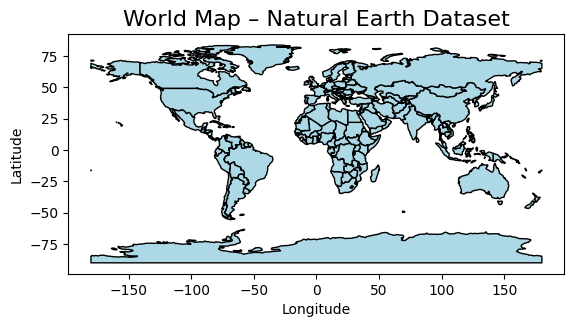

In [25]:
plt.figure(figsize=(15,10))
world.plot(
    color="lightblue",
    edgecolor="black"
)

plt.title("World Map – Natural Earth Dataset", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Check columns and geometry type

In [26]:
print("Number of columns:", len(world.columns))
print("Geometry types:", world.geom_type.unique())

Number of columns: 169
Geometry types: ['MultiPolygon' 'Polygon']


Check Coordinate Reference System


In [27]:
print("Current CRS:", world.crs)

Current CRS: EPSG:4326


Reproject to EPSG:3857

In [28]:
world_projected = world.to_crs(epsg=3857)

Compute Area

In [29]:
world_projected["area_m2"] = world_projected.geometry.area
world_projected[["ADMIN", "area_m2"]].head()

,ADMIN,area_m2
0,Fiji,2.128334e+10
1,United Republic of Tanzania,9.522552e+11
2,Western Sahara,1.171023e+11
3,Canada,5.216648e+13
4,United States of America,2.186228e+13


Get Centroid

In [30]:
world_projected["centroid"] = world_projected.geometry.centroid

Extract X and Y

In [31]:
world_projected["x"] = world_projected.centroid.x
world_projected["y"] = world_projected.centroid.y

world_projected[["ADMIN", "x", "y"]].head()

,ADMIN,x,y
0,Fiji,1.824878e+07,-1.958098e+06
1,United Republic of Tanzania,3.869296e+06,-7.003071e+05
2,Western Sahara,-1.348403e+06,2.794163e+06
3,Canada,-1.079779e+07,1.044422e+07
4,United States of America,-1.329713e+07,6.667416e+06


Get the top 10 largest Countries

In [32]:
top10 = world_projected.sort_values("area_m2", ascending=False).head(10)

top10[["ADMIN", "area_m2"]]

,ADMIN,area_m2
159,Antarctica,9.204514e+15
18,Russia,8.304514e+13
3,Canada,5.216648e+13
22,Greenland,3.628550e+13
4,United States of America,2.186228e+13
139,China,1.497731e+13
137,Australia,9.651737e+12
29,Brazil,9.059541e+12
5,Kazakhstan,6.177084e+12
9,Argentina,4.328068e+12


Plot the top 10 countries

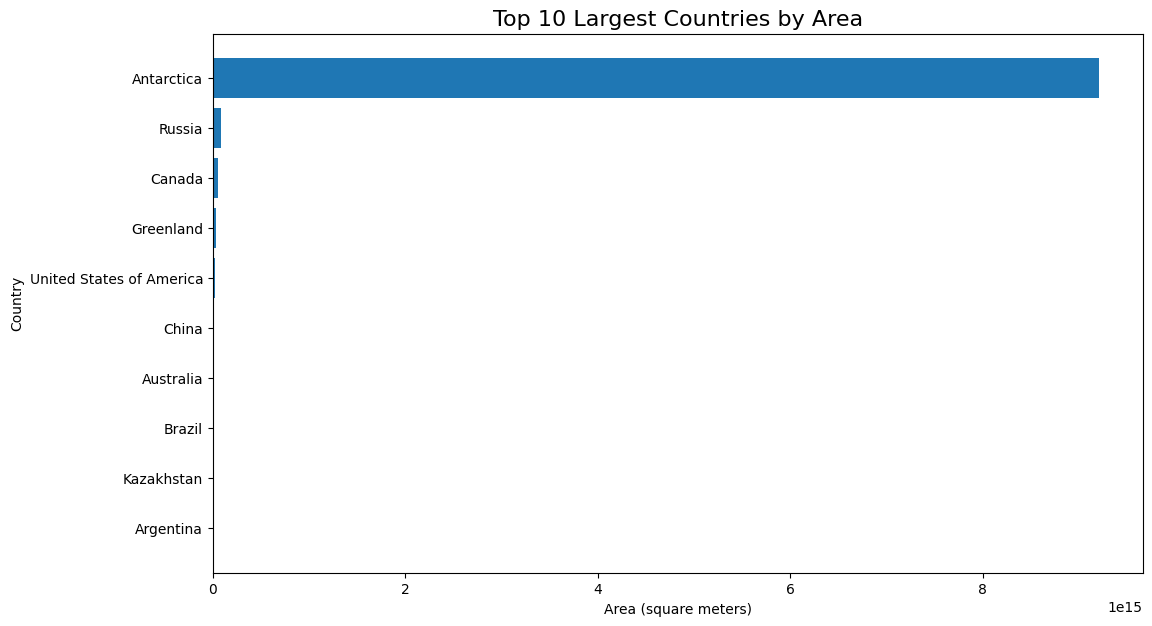

In [33]:
plt.figure(figsize=(12,7))

plt.barh(top10["ADMIN"], top10["area_m2"])

plt.title("Top 10 Largest Countries by Area", fontsize=16)
plt.xlabel("Area (square meters)")
plt.ylabel("Country")

plt.gca().invert_yaxis()   # Largest on top
plt.show()

# **GUIDE QUESTION ANSWERS**

**TASK 2 – Load Natural Earth Dataset**

1. How many columns does the dataset contain?

The dataset contains many attribute columns (160+ depending on the version) including one geometry column.

2. What type of geometries are included?

The dataset includes polygon and multipolygon geometries that represent country boundaries.

3. What does the geometry column represent?

The geometry column stores the spatial shape and geographic location of each country.

**TASK 3 – Check the Coordinate Reference System**

1. What does EPSG:4326 represent?

EPSG:4326 represents the WGS84 geographic coordinate system that uses latitude and longitude in degrees.

2. Why is CRS important in spatial analysis?

CRS is important because it ensures that spatial data aligns correctly and that measurements like distance and area are accurate.

**TASK 4 – Convert to Metric CRS for Area Calculation**

1. Why can't we compute area accurately using EPSG:4326?

Area cannot be computed accurately in EPSG:4326 because it uses degrees instead of a linear unit like meters.

2. What unit is EPSG:3857 based on?

EPSG:3857 is based on meters as its unit of measurement.

**TASK 5 – Extract Centroid Coordinates**

1. What is a centroid?

A centroid is the geometric center point of a spatial feature.

2. How can centroid coordinates be used in clustering?

Centroid coordinates can be used as numerical spatial features to group locations based on proximity.

3. Why do we extract X and Y separately?

X and Y are extracted separately because machine learning algorithms require numeric feature columns rather than geometry data.

# **Reflection**

  During the activity, I initially struggled with understanding why the coordinate reference system had to be changed before calculating the area, since the map already looked correct in its original form. I also encountered some confusion in extracting centroid coordinates and making sure the correct projected dataset was used for plotting the top 10 largest countries. Through this exercise, I learned that spatial data is not just about visualizing maps but also about using the proper CRS to obtain accurate measurements and meaningful analysis. I realized that geometries store real-world locations and can be converted into numerical features like area and coordinates for further data analysis. Overall, the activity helped me appreciate the importance of preprocessing and transforming spatial data before performing computations and visualizations.